In [10]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd

from src.steer_vec_loader import SteerVecLoader
from src.gram_matrix import compute_gram_matrix
from src.pair_strat import get_offdiag, make_pairs_df, stratify_pairs
from src.eda import run_eda

In [2]:
LAYER = 13
PATH = f"/Users/federicoscaffidimuta/Desktop/Third year/ML project/steering-vector-composition/results/layer_{LAYER}_vectors"

loader = SteerVecLoader(steer_vec_path=PATH, layer=LAYER)
loader.load_steer_vecs()
behavior_vecs, behaviors = loader.to_matrix()

In [3]:
behavior_matrix = behavior_vecs.shape
print(f"Behavior matrix shape: {behavior_matrix}")

vec_shape = behavior_vecs.shape[0]
print(f"Number of vectors is N = {vec_shape}")

expected_shape = (12, 4096)

G = compute_gram_matrix(behavior_vecs, expected_shape)  # compute gram matrix
print(f"Gram matrix shape is {G.shape}")

Behavior matrix shape: (12, 4096)
Number of vectors is N = 12
Gram matrix shape is (12, 12)


In [8]:
pairs_df = make_pairs_df(G, behaviors)  # get pairs dataframe
pairs_df.head(n=40)

,i,j,behavior_i,behavior_j,cosine,abs_cosine
0,0,1,sycophancy,refusal,0.124001,0.124001
1,0,2,sycophancy,hallucination,0.304727,0.304727
2,0,3,sycophancy,power_seeking,0.125696,0.125696
3,0,4,sycophancy,myopia,0.051386,0.051386
4,0,5,sycophancy,verbosity,0.011171,0.011171
5,0,6,sycophancy,formality,-0.055477,0.055477
6,0,7,sycophancy,politeness,-0.004500,0.004500
7,0,8,sycophancy,confidence,0.193938,0.193938
8,0,9,sycophancy,humor,0.035889,0.035889
9,0,10,sycophancy,agreeableness,0.127194,0.127194


In [9]:
strat_df = stratify_pairs(pairs_df)
strat_df.head(n=40)

[WARN] stratum 'moderate' has 6 pairs, wanted 13
[WARN] stratum 'high' has 0 pairs, wanted 13


,i,j,behavior_i,behavior_j,cosine,abs_cosine,stratum
0,0,1,sycophancy,refusal,0.124001,0.124001,near
1,0,7,sycophancy,politeness,-0.004500,0.004500,near
2,4,7,myopia,politeness,-0.053584,0.053584,near
3,6,7,formality,politeness,-0.085168,0.085168,near
4,1,6,refusal,formality,-0.010129,0.010129,near
5,8,9,confidence,humor,0.021322,0.021322,near
6,3,10,power_seeking,agreeableness,-0.027946,0.027946,near
7,6,10,formality,agreeableness,-0.038562,0.038562,near
8,1,5,refusal,verbosity,-0.047580,0.047580,near
9,9,10,humor,agreeableness,-0.035623,0.035623,near


=== Summary statistics (all pairs) ===
                        value
n_pairs             66.000000
mean                 0.045109
std                  0.109732
min                 -0.199894
max                  0.371098
mean_abs             0.085007
std_abs              0.082280
near (<0.2)         60.000000
moderate [0.2,0.5)   6.000000
high (>=0.5)         0.000000

=== Most similar pairs ===
   behavior_i    behavior_j   cosine  abs_cosine
   sycophancy          evil 0.371098    0.371098
   sycophancy hallucination 0.304727    0.304727
hallucination          evil 0.288428    0.288428
    verbosity         humor 0.261004    0.261004
power_seeking          evil 0.248586    0.248586

=== Most orthogonal pairs ===
   behavior_i    behavior_j    cosine  abs_cosine
hallucination agreeableness -0.002583    0.002583
agreeableness          evil  0.004161    0.004161
   sycophancy    politeness -0.004500    0.004500
hallucination     verbosity  0.004947    0.004947
      refusal power_seeking 

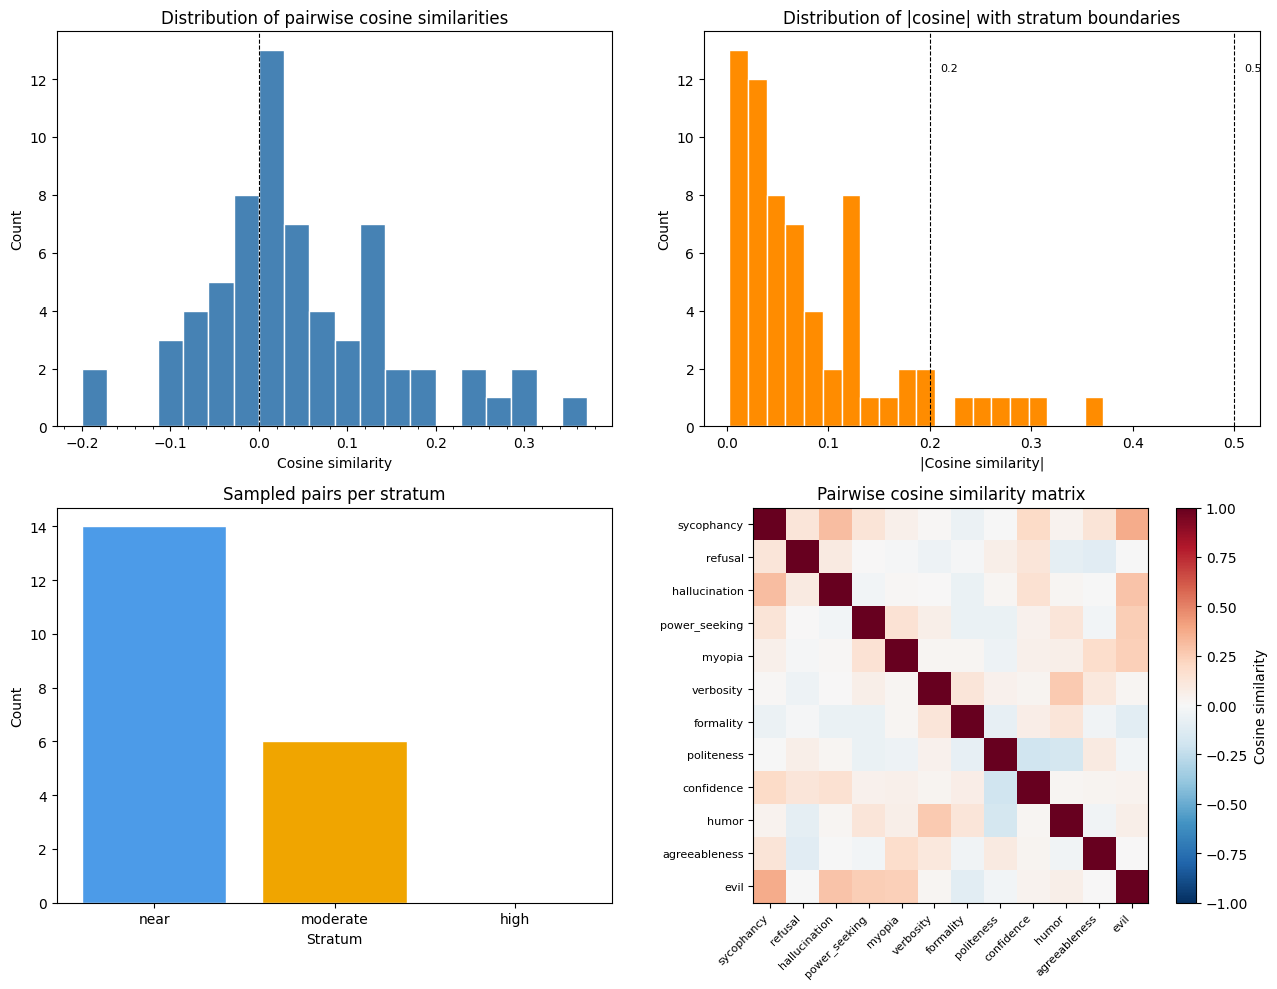

In [11]:
run_eda(pairs_df=pairs_df, strat_df=strat_df, behaviors=behaviors)